In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


# 0. SETUP(Importing Libraries)

In [2]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
t_start = time.time()
def elapsed(): return round(time.time() - t_start, 1)


# 1. Load Data

In [3]:
DATA_DIR = "/kaggle/input/competitions/comment-category-prediction-challenge"
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/Sample.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()


Train shape: (198000, 15)
Test shape : (102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


# 2. EXPLORATORY DATA ANALYSIS

## 2.1 Missing values

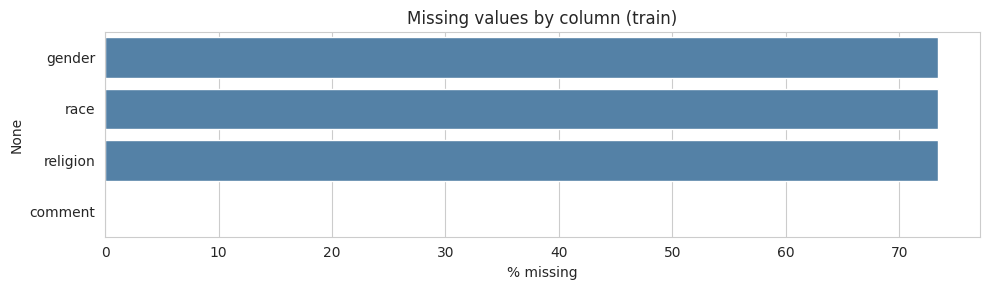

In [4]:
missing = train.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
if len(missing):
    plt.figure(figsize=(10, max(3, len(missing) * 0.35)))
    sns.barplot(x=missing.values, y=missing.index, color="steelblue")
    plt.xlabel("% missing")
    plt.title("Missing values by column (train)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in train.")


## 2.2 Target class distribution
The label is heavily imbalanced — this is exactly why plain accuracy was a misleading signal earlier and macro-F1 (which weights every class equally) is the metric that actually tracks the leaderboard.

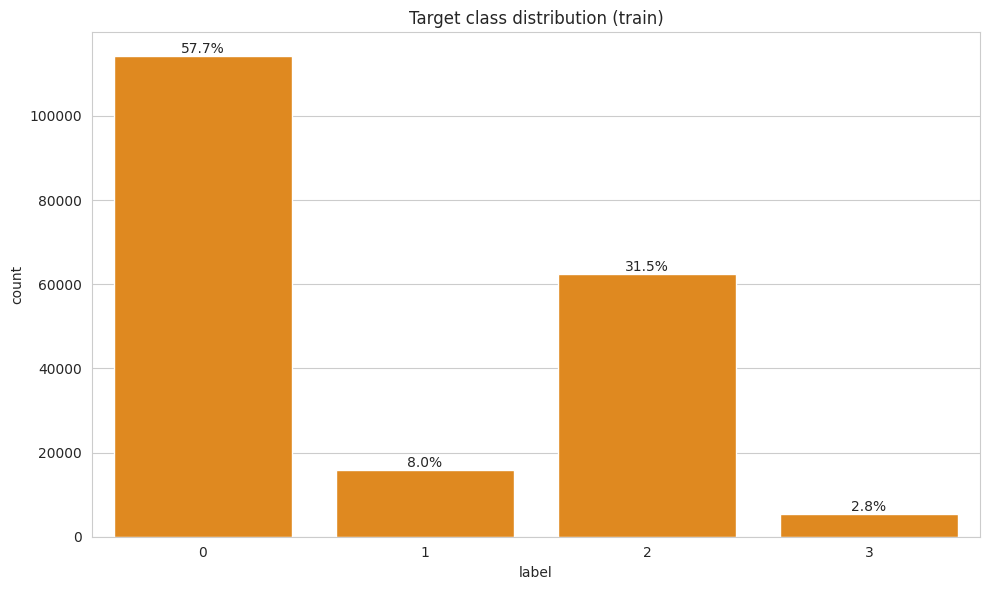

label
0    57.66
1     8.04
2    31.54
3     2.76
Name: proportion, dtype: float64


In [5]:
class_counts = train["label"].value_counts().sort_index()
class_pct = train["label"].value_counts(normalize=True).sort_index() * 100

plt.figure()
ax = sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, color="darkorange")
for i, (cnt, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    ax.text(i, cnt, f"{pct:.1f}%", ha="center", va="bottom")
plt.xlabel("label")
plt.ylabel("count")
plt.title("Target class distribution (train)")
plt.tight_layout()
plt.show()

print(class_pct.round(2))


## 2.3 Comment length & word count by class

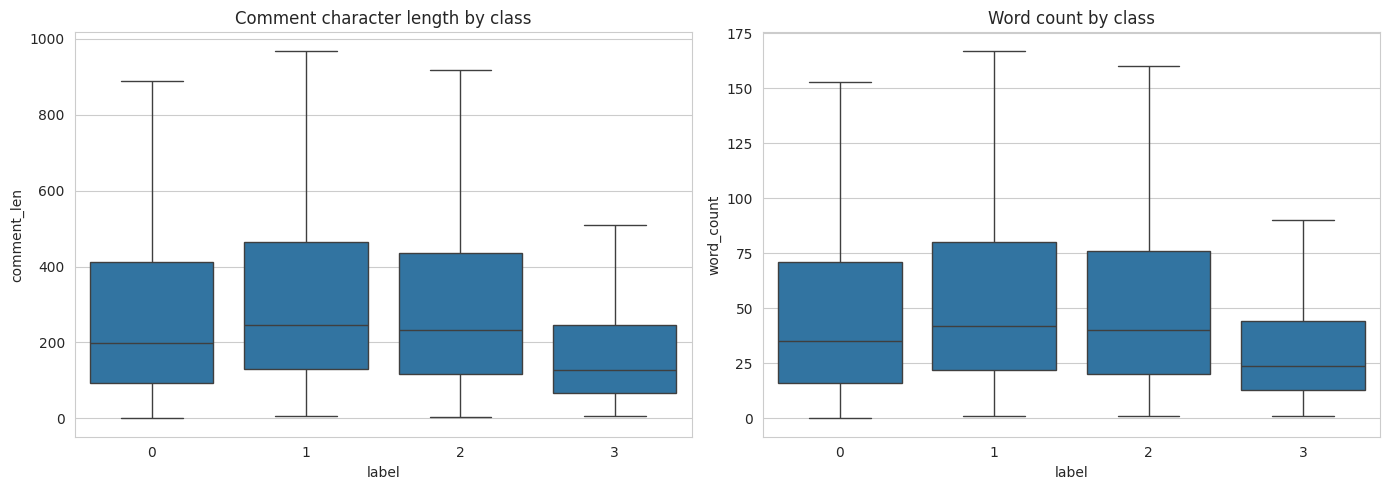

In [6]:
tmp = train.copy()
tmp["comment"] = tmp["comment"].fillna("")
tmp["comment_len"] = tmp["comment"].str.len()
tmp["word_count"] = tmp["comment"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=tmp, x="label", y="comment_len", ax=axes[0], showfliers=False)
axes[0].set_title("Comment character length by class")
sns.boxplot(data=tmp, x="label", y="word_count", ax=axes[1], showfliers=False)
axes[1].set_title("Word count by class")
plt.tight_layout()
plt.show()


## 2.4 Engagement (votes) by class

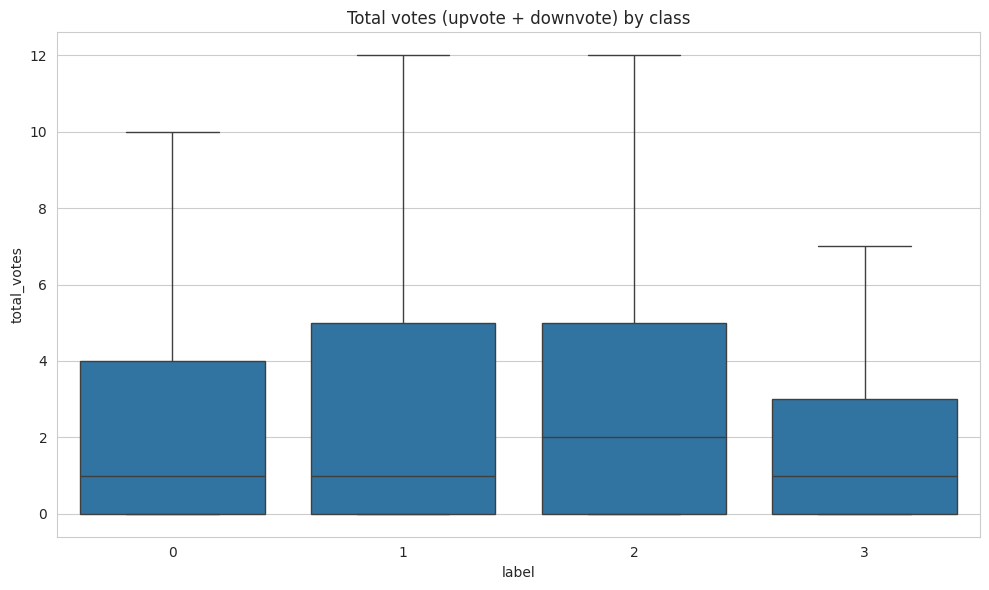

In [7]:
tmp["total_votes"] = pd.to_numeric(tmp.get("upvote", 0), errors="coerce").fillna(0) + \
                      pd.to_numeric(tmp.get("downvote", 0), errors="coerce").fillna(0)

plt.figure()
sns.boxplot(data=tmp, x="label", y="total_votes", showfliers=False)
plt.title("Total votes (upvote + downvote) by class")
plt.tight_layout()
plt.show()


## 2.5 Topic / identity flag prevalence by class
How often each system-detected flag (`race`, `religion`, `gender`, `disability`) fires, broken out by target class — a quick read on which flags actually separate the classes.

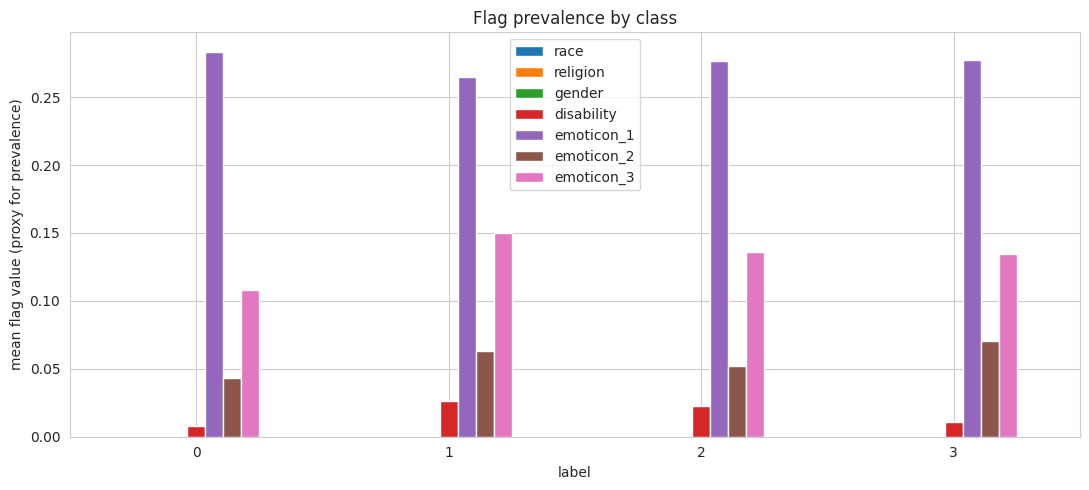

In [8]:
flag_cols = [c for c in ["race", "religion", "gender", "disability",
                          "emoticon_1", "emoticon_2", "emoticon_3"] if c in train.columns]
if flag_cols:
    flag_numeric = train[flag_cols].apply(pd.to_numeric, errors="coerce")
    flag_by_class = flag_numeric.groupby(train["label"]).mean()
    flag_by_class.plot(kind="bar", figsize=(11, 5))
    plt.ylabel("mean flag value (proxy for prevalence)")
    plt.title("Flag prevalence by class")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    flag_by_class.round(3)


## 2.6 Correlation among numeric/engagement features

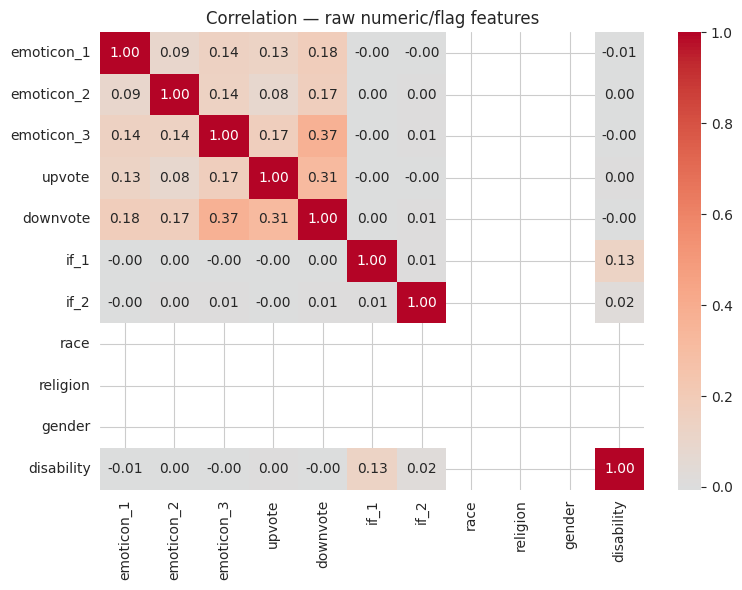

In [9]:
num_candidates = [c for c in ["emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote",
                               "if_1", "if_2", "race", "religion", "gender", "disability"]
                  if c in train.columns]
if len(num_candidates) > 1:
    corr = train[num_candidates].apply(pd.to_numeric, errors="coerce").fillna(0).corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation — raw numeric/flag features")
    plt.tight_layout()
    plt.show()


**EDA takeaways**
- The target is heavily imbalanced (see 2.2) — this is why every model below is trained with `class_weight="balanced"` where supported, and why macro-F1 (not accuracy) drives every modeling decision from here on.
- Comment length, word count, and vote patterns differ visibly across classes (2.3, 2.4), which is why they're included as engineered features alongside the raw text.
- If any flag in 2.5 or 2.6 turns out to be near-constant or perfectly correlated with another, it's a candidate to drop in a future iteration — nothing dropped yet, just noted.

# 3. FEATURE ENGINEERING

In [10]:
def text_features(df):
    df["comment"] = df["comment"].fillna("")
    c = df["comment"]
    df["comment_len"] = c.str.len()
    df["word_count"] = c.str.split().apply(len)
    df["avg_word_len"] = df["comment_len"] / (df["word_count"] + 1)
    df["unique_word_ratio"] = c.apply(lambda s: len(set(s.split())) / (len(s.split()) + 1))
    df["upper_ratio"] = c.apply(lambda s: sum(ch.isupper() for ch in s) / (len(s) + 1))
    df["digit_ratio"] = c.apply(lambda s: sum(ch.isdigit() for ch in s) / (len(s) + 1))
    df["excl_count"] = c.str.count("!")
    df["quest_count"] = c.str.count(r"\?")
    df["punct_count"] = c.apply(lambda s: sum(ch in ".,;:!?" for ch in s))
    return df

def date_features(df):
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df["hour"] = df["created_date"].dt.hour
    df["dayofweek"] = df["created_date"].dt.dayofweek
    df["month"] = df["created_date"].dt.month
    for col in ["hour", "dayofweek", "month"]:
        df[col] = df[col].fillna(-1)
    return df

def engineer(df):
    df = df.copy()
    df = text_features(df)
    df = date_features(df)
    up = pd.to_numeric(df.get("upvote", 0), errors="coerce").fillna(0)
    down = pd.to_numeric(df.get("downvote", 0), errors="coerce").fillna(0)
    df["total_votes"] = up + down
    df["vote_ratio"] = (up - down) / (df["total_votes"] + 1)
    df["log_total_votes"] = np.log1p(df["total_votes"])
    return df

train = engineer(train)
test = engineer(test)

if "post_id" in train.columns:
    combined_counts = pd.concat([train["post_id"], test["post_id"]]).value_counts()
    train["post_comment_count"] = train["post_id"].map(combined_counts)
    test["post_comment_count"] = test["post_id"].map(combined_counts)

num_cols = [
    "emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2",
    "race", "religion", "gender", "disability",
    "comment_len", "word_count", "avg_word_len", "unique_word_ratio",
    "upper_ratio", "digit_ratio", "excl_count", "quest_count", "punct_count",
    "hour", "dayofweek", "month", "total_votes", "vote_ratio", "log_total_votes",
    "post_comment_count",
]
num_cols = [c for c in num_cols if c in train.columns]
for c in num_cols:
    train[c] = pd.to_numeric(train[c], errors="coerce").fillna(0)
    test[c] = pd.to_numeric(test[c], errors="coerce").fillna(0)

le = LabelEncoder()
y = le.fit_transform(train["label"])
n_classes = len(le.classes_)
print("classes:", list(le.classes_))
print("class balance (train):")
print(pd.Series(y).value_counts(normalize=True).sort_index())


classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
class balance (train):
0    0.576631
1    0.080394
2    0.315354
3    0.027621
Name: proportion, dtype: float64


# 4. TEXT VECTORIZATION (TF-IDF, word-level)

In [11]:
word_tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=3,
                              sublinear_tf=True, stop_words="english")
Xw_train = word_tfidf.fit_transform(train["comment"])
Xw_test = word_tfidf.transform(test["comment"])
print("TF-IDF done:", elapsed(), "s elapsed —", Xw_train.shape[1], "features")


TF-IDF done: 48.7 s elapsed — 10000 features


# 5. ASSEMBLE FEATURE MATRICES

In [12]:
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train[num_cols])
X_num_test = scaler.transform(test[num_cols])

X_sparse_train = hstack([Xw_train, csr_matrix(X_num_train)]).tocsr()
X_sparse_test = hstack([Xw_test, csr_matrix(X_num_test)]).tocsr()


# 6. TRAIN / VALIDATION SPLIT

In [13]:
idx_tr, idx_val = train_test_split(
    np.arange(len(y)), test_size=0.12, random_state=RANDOM_STATE, stratify=y
)
Xs_tr, Xs_val = X_sparse_train[idx_tr], X_sparse_train[idx_val]
Xw_tr, Xw_val = Xw_train[idx_tr], Xw_train[idx_val]
Xn_tr, Xn_val = X_num_train[idx_tr], X_num_train[idx_val]
y_tr, y_val = y[idx_tr], y[idx_val]

def evaluate(name, proba):
    pred = proba.argmax(axis=1)
    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred, average="macro")
    print(f"{name:24s} | val accuracy = {acc:.4f} | macro-F1 = {f1:.4f}")
    return acc, f1

val_probas, acc_scores, f1_scores = {}, {}, {}


# 7. MODEL TRAINING

## 7.1 Logistic Regression (class-weighted)

In [14]:
lr = LogisticRegression(max_iter=1000, C=1.5, solver="lbfgs",
                         multi_class="multinomial", class_weight="balanced", n_jobs=-1)
lr.fit(Xs_tr, y_tr)
val_probas["lr"] = lr.predict_proba(Xs_val)
acc_scores["lr"], f1_scores["lr"] = evaluate("Logistic Regression", val_probas["lr"])
print("elapsed:", elapsed(), "s")


Logistic Regression      | val accuracy = 0.8886 | macro-F1 = 0.7728
elapsed: 82.2 s


## 7.2 Complement Naive Bayes

In [15]:
cnb = ComplementNB(alpha=0.3)
cnb.fit(Xw_tr, y_tr)
val_probas["cnb"] = cnb.predict_proba(Xw_val)
acc_scores["cnb"], f1_scores["cnb"] = evaluate("Complement NB", val_probas["cnb"])
print("elapsed:", elapsed(), "s")


Complement NB            | val accuracy = 0.6924 | macro-F1 = 0.6114
elapsed: 82.2 s


## 7.3 SGD (log-loss, class-weighted)

In [16]:
sgd = SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=80, class_weight="balanced",
                     random_state=RANDOM_STATE, n_jobs=-1)
sgd.fit(Xs_tr, y_tr)
val_probas["sgd"] = sgd.predict_proba(Xs_val)
acc_scores["sgd"], f1_scores["sgd"] = evaluate("SGD (log-loss)", val_probas["sgd"])
print("elapsed:", elapsed(), "s")


SGD (log-loss)           | val accuracy = 0.8874 | macro-F1 = 0.7754
elapsed: 86.9 s


## 7.4 LightGBM

In [17]:
lgbm = LGBMClassifier(
    n_estimators=150, learning_rate=0.09, num_leaves=31, feature_fraction=0.3,
    subsample=0.8, max_bin=127, min_child_samples=30, class_weight="balanced",
    objective="multiclass", num_class=n_classes, random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=-1,
)
lgbm.fit(Xs_tr, y_tr)
val_probas["lgbm"] = lgbm.predict_proba(Xs_val)
acc_scores["lgbm"], f1_scores["lgbm"] = evaluate("LightGBM", val_probas["lgbm"])
print("elapsed:", elapsed(), "s")


LightGBM                 | val accuracy = 0.8919 | macro-F1 = 0.7732
elapsed: 192.4 s


## 7.5 Random Forest (numeric/engineered features only)

In [18]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced_subsample",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(Xn_tr, y_tr)
val_probas["rf"] = rf.predict_proba(Xn_val)
acc_scores["rf"], f1_scores["rf"] = evaluate("Random Forest (numeric)", val_probas["rf"])
print("elapsed:", elapsed(), "s")


Random Forest (numeric)  | val accuracy = 0.7854 | macro-F1 = 0.5896
elapsed: 211.5 s


# 8. MODEL COMPARISON

In [19]:
model_labels = {"lr": "Logistic Regression", "cnb": "Complement NB", "sgd": "SGD (log-loss)",
                 "lgbm": "LightGBM", "rf": "Random Forest"}

comparison = pd.DataFrame({
    "model": [model_labels[m] for m in val_probas],
    "val_accuracy": [acc_scores[m] for m in val_probas],
    "val_macro_f1": [f1_scores[m] for m in val_probas],
}).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
comparison


,model,val_accuracy,val_macro_f1
0,SGD (log-loss),0.887416,0.775450
1,LightGBM,0.891877,0.773231
2,Logistic Regression,0.888636,0.772795
3,Complement NB,0.692424,0.611403
4,Random Forest,0.785438,0.589596


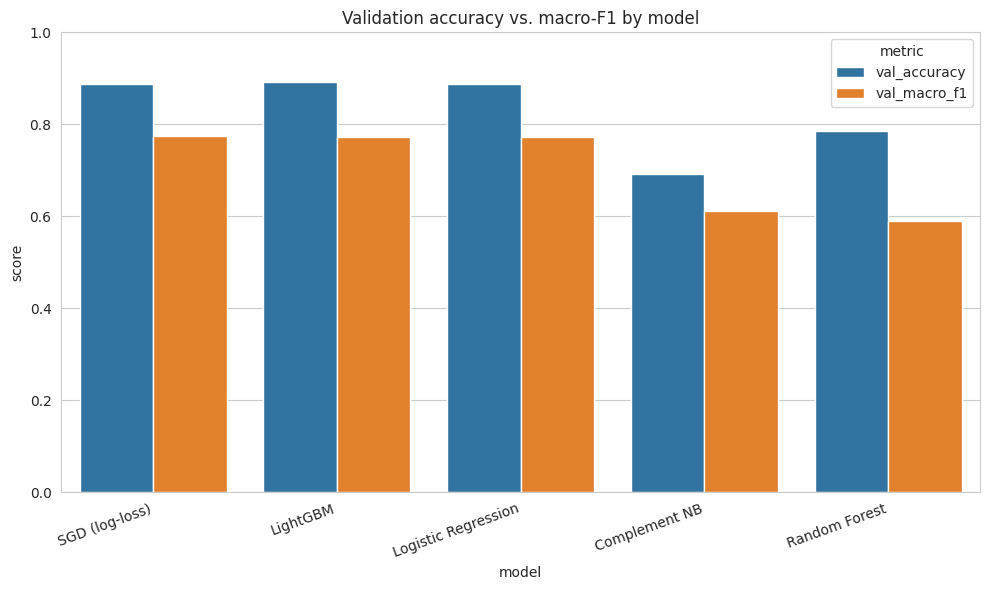

In [20]:
plot_df = comparison.melt(id_vars="model", value_vars=["val_accuracy", "val_macro_f1"],
                           var_name="metric", value_name="score")
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Validation accuracy vs. macro-F1 by model")
plt.tight_layout()
plt.show()


**Reading this chart:** a model whose accuracy bar is much taller than its macro-F1 bar is leaning on the majority class rather than genuinely separating all four categories — that gap is exactly what made the earlier accuracy-weighted blend backfire. Models are ranked by macro-F1 below since that's what the leaderboard tracks.

## 8.1 Confusion matrix — best single model

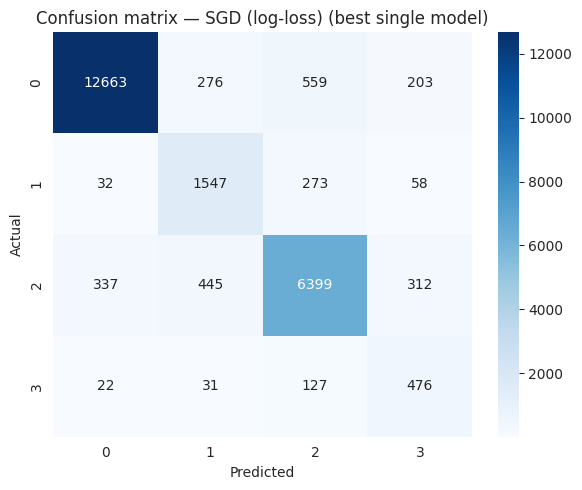

In [21]:
best_single = comparison.iloc[0]["model"]
best_key = [k for k, v in model_labels.items() if v == best_single][0]
cm = confusion_matrix(y_val, val_probas[best_key].argmax(axis=1))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_single} (best single model)")
plt.tight_layout()
plt.show()


# 9. ENSEMBLE — COORDINATE-ASCENT BLEND
Cycles through every model a few rounds; for each one, tries a fine grid of weights with everyone else held fixed and keeps whatever raises validation macro-F1. A model that never helps settles at weight 0, so the blend can only match or beat the best single model.

In [22]:
model_names = list(val_probas.keys())
weights = {m: 1.0 / len(model_names) for m in model_names}
grid = [round(x, 2) for x in np.arange(0.0, 1.01, 0.05)]

def macro_f1_of(w):
    total = sum(w.values())
    if total <= 0:
        return -1.0
    ens = sum((w[m] / total) * val_probas[m] for m in w)
    return f1_score(y_val, ens.argmax(axis=1), average="macro")

current_f1 = macro_f1_of(weights)
print(f"Start (equal weights): macro-F1 = {current_f1:.4f}")

for round_ in range(3):
    improved = False
    for m in model_names:
        best_w, best_f1_local = weights[m], current_f1
        for w in grid:
            trial = dict(weights); trial[m] = w
            f1_trial = macro_f1_of(trial)
            if f1_trial > best_f1_local:
                best_f1_local, best_w = f1_trial, w
        if best_w != weights[m]:
            weights[m] = best_w
            current_f1 = best_f1_local
            improved = True
    print(f"Round {round_ + 1}: macro-F1 = {current_f1:.4f}, weights = {{k: round(v,3) for k,v in weights.items()}}")
    if not improved:
        print("No further improvement, stopping early.")
        break

total_w = sum(weights.values())
weights = {m: w / total_w for m, w in weights.items()}
print("\nFinal ensemble weights:", {k: round(v, 3) for k, v in weights.items()})
ensemble_val = sum(weights[m] * val_probas[m] for m in weights)
ens_acc, ens_f1 = evaluate("FINAL ENSEMBLE (validation)", ensemble_val)
print("elapsed:", elapsed(), "s")


Start (equal weights): macro-F1 = 0.7931
Round 1: macro-F1 = 0.7957, weights = {k: round(v,3) for k,v in weights.items()}
Round 2: macro-F1 = 0.7990, weights = {k: round(v,3) for k,v in weights.items()}
Round 3: macro-F1 = 0.7993, weights = {k: round(v,3) for k,v in weights.items()}

Final ensemble weights: {'lr': np.float64(0.0), 'cnb': np.float64(0.233), 'sgd': np.float64(0.433), 'lgbm': np.float64(0.2), 'rf': np.float64(0.133)}
FINAL ENSEMBLE (validation) | val accuracy = 0.9018 | macro-F1 = 0.7993
elapsed: 212.8 s


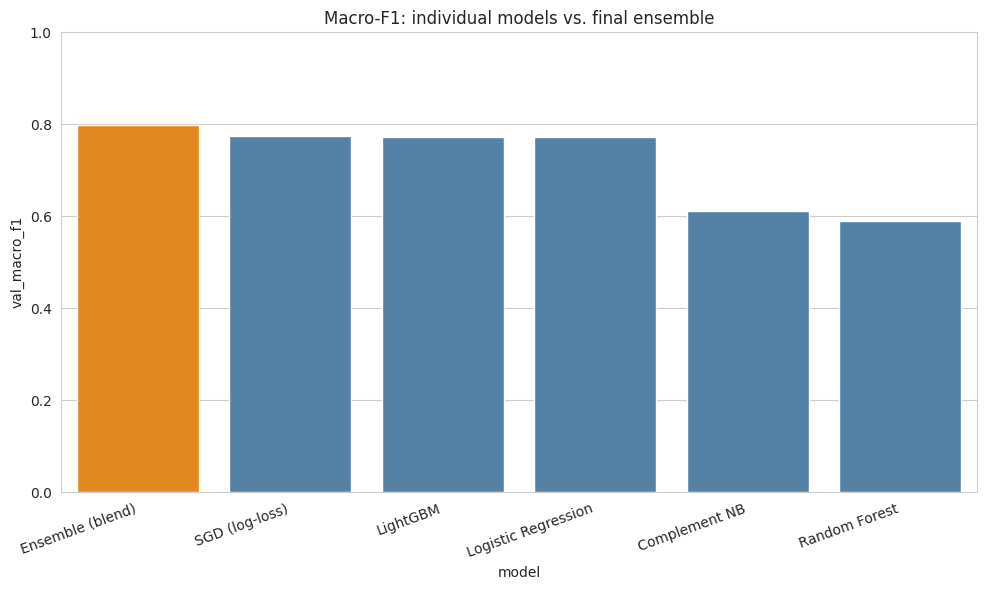

,model,val_accuracy,val_macro_f1
0,Ensemble (blend),0.901768,0.799289
1,SGD (log-loss),0.887416,0.775450
2,LightGBM,0.891877,0.773231
3,Logistic Regression,0.888636,0.772795
4,Complement NB,0.692424,0.611403
5,Random Forest,0.785438,0.589596


In [23]:
final_comparison = pd.concat([
    comparison,
    pd.DataFrame([{"model": "Ensemble (blend)", "val_accuracy": ens_acc, "val_macro_f1": ens_f1}])
], ignore_index=True).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
colors = ["darkorange" if m == "Ensemble (blend)" else "steelblue" for m in final_comparison["model"]]
sns.barplot(data=final_comparison, x="model", y="val_macro_f1", palette=colors)
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Macro-F1: individual models vs. final ensemble")
plt.tight_layout()
plt.show()

final_comparison


# 10. REFIT ON FULL TRAINING DATA, PREDICT TEST

In [24]:
fit_full = {}
if weights.get("lr", 0) > 0:
    lr.fit(X_sparse_train, y); fit_full["lr"] = lr.predict_proba(X_sparse_test)
if weights.get("cnb", 0) > 0:
    cnb.fit(Xw_train, y); fit_full["cnb"] = cnb.predict_proba(Xw_test)
if weights.get("sgd", 0) > 0:
    sgd.fit(X_sparse_train, y); fit_full["sgd"] = sgd.predict_proba(X_sparse_test)
if weights.get("lgbm", 0) > 0:
    lgbm.fit(X_sparse_train, y); fit_full["lgbm"] = lgbm.predict_proba(X_sparse_test)
if weights.get("rf", 0) > 0:
    rf.fit(X_num_train, y); fit_full["rf"] = rf.predict_proba(X_num_test)

active = {m: w for m, w in weights.items() if m in fit_full}
active_total = sum(active.values())
active = {m: w / active_total for m, w in active.items()}
print("Models actually refit and used:", active)

blend_test = sum(active[m] * fit_full[m] for m in active)
test_pred = blend_test.argmax(axis=1)
test_labels = le.inverse_transform(test_pred)
print("elapsed:", elapsed(), "s")


Models actually refit and used: {'cnb': np.float64(0.23333333333333334), 'sgd': np.float64(0.4333333333333334), 'lgbm': np.float64(0.2), 'rf': np.float64(0.13333333333333336)}
elapsed: 362.9 s


# 11. SUBMISSION

In [25]:
id_col = sample_sub.columns[0]
label_col = sample_sub.columns[1]
if id_col in test.columns:
    ids = test[id_col]
else:
    ids = np.arange(1, len(test) + 1)

submission = pd.DataFrame({id_col: ids, label_col: test_labels})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Saved submission.csv with shape", submission.shape)
print("TOTAL RUNTIME:", round((time.time() - t_start) / 60, 2), "minutes")


   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
Saved submission.csv with shape (102000, 2)
TOTAL RUNTIME: 6.05 minutes


**Summary**
- EDA confirmed heavy class imbalance, motivating `class_weight="balanced"` and macro-F1 as the model-selection metric throughout.
- 5 models trained: Logistic Regression, Complement NB, SGD, LightGBM, Random Forest — see Section 8 for the individual accuracy-vs-macro-F1 comparison and confusion matrix.
- Final prediction is a coordinate-ascent-weighted blend of whichever models actually improved validation macro-F1 (Section 9) — a model that didn't help settles at weight 0 and is skipped at refit time, so no wasted compute in Section 10.
- Modeling logic is unchanged from the working 0.796 submission; this version adds the EDA and comparison sections around it.